<a href="https://www.kaggle.com/code/kaushikfreddyregalla/03-custom-cnn-model?scriptVersionId=325237156" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 03 — Custom CNN Model
Hand Gesture Recognition | Kaushik Reddy Ragalla

In [24]:
import numpy as np, os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Auto-find .npy files
NPY_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'X_train.npy' in files:
        NPY_DIR = root
        break
if NPY_DIR is None and os.path.exists('/kaggle/working/X_train.npy'):
    NPY_DIR = '/kaggle/working'
assert NPY_DIR, 'X_train.npy not found!'
print(f'Loading from: {NPY_DIR}')

X_train = np.load(f'{NPY_DIR}/X_train.npy')
y_train = np.load(f'{NPY_DIR}/y_train.npy')
X_val   = np.load(f'{NPY_DIR}/X_val.npy')
y_val   = np.load(f'{NPY_DIR}/y_val.npy')
X_test  = np.load(f'{NPY_DIR}/X_test.npy')
y_test  = np.load(f'{NPY_DIR}/y_test.npy')
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

NUM_CLASSES = 10
BATCH_SIZE  = 32
EPOCHS      = 30
SEED        = 42

train_datagen = ImageDataGenerator(
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1, horizontal_flip=True, fill_mode='nearest')
val_datagen = ImageDataGenerator()
train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen   = val_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)
print('Data generators ready.')


Loading from: /kaggle/input/notebooks/kaushikfreddyregalla/02-preprocessing-data-augmentation
Train: (14000, 128, 128, 1), Val: (3000, 128, 128, 1), Test: (3000, 128, 128, 1)
Data generators ready.


In [25]:
# ── Augmentation generators ──────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1, horizontal_flip=True, fill_mode='nearest')
val_datagen = ImageDataGenerator()

train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen   = val_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)

In [26]:
# ── Build Custom CNN ─────────────────────────────────────────────────────────
# 4 convolutional blocks with BatchNorm and Dropout
# GlobalAveragePooling + Dense classification head

def build_custom_cnn(input_shape=(128, 128, 1), num_classes=10):
    inp = layers.Input(shape=input_shape)

    # Block 1 — 32 filters
    x = layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 2 — 64 filters
    x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 3 — 128 filters
    x = layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 4 — 256 filters
    x = layers.Conv2D(256, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inp, outputs=out, name='CustomCNN')

cnn_model = build_custom_cnn()
cnn_model.summary()

Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 652,778 (2.49 MB)

 Trainable params: 651,370 (2.48 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [27]:
# ── Compile ──────────────────────────────────────────────────────────────────
cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_custom_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [28]:
# ── Train ────────────────────────────────────────────────────────────────────
steps = len(X_train) // BATCH_SIZE

cnn_history = cnn_model.fit(
    train_gen,
    steps_per_epoch=steps,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=cnn_callbacks,
    verbose=1
)
print('Training complete.')

Epoch 1/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5304 - loss: 1.4364
Epoch 1: val_accuracy improved from None to 0.28833, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 44s 76ms/step - accuracy: 0.7265 - loss: 0.9071 - val_accuracy: 0.2883 - val_loss: 2.4993 - learning_rate: 0.0010
Epoch 2/30
  1/437 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9375 - loss: 0.5470
Epoch 2: val_accuracy did not improve from 0.28833
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9375 - loss: 0.5470 - val_accuracy: 0.2673 - val_loss: 2.5069 - learning_rate: 0.0010
Epoch 3/30
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9373 - loss: 0.3048
Epoch 3: val_accuracy improved from 0.28833 to 0.95200, saving model to best_custom_cnn.keras

Epoch 3: finished saving model to best_custom_cnn.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.9434 - loss: 0.2825 - val_accuracy: 0.9520 - va

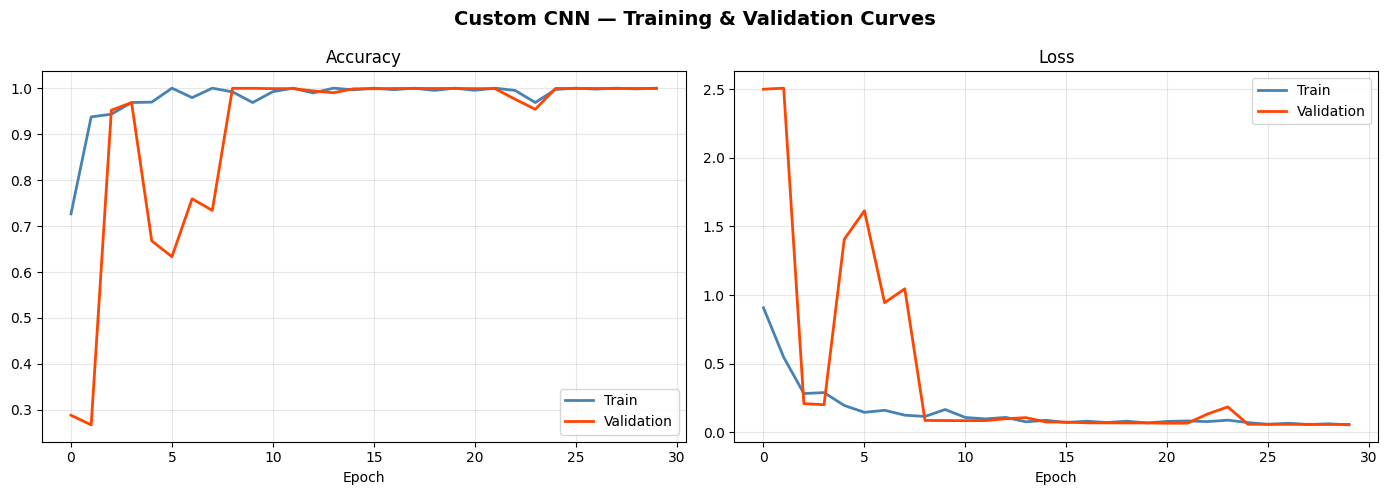


Test Accuracy (Custom CNN): 99.90%


In [29]:
# ── Training Curves ──────────────────────────────────────────────────────────
import os
os.makedirs('figures', exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Custom CNN — Training & Validation Curves', fontsize=14, fontweight='bold')

ax1.plot(cnn_history.history['accuracy'],     label='Train',      color='steelblue', lw=2)
ax1.plot(cnn_history.history['val_accuracy'], label='Validation', color='orangered', lw=2)
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(cnn_history.history['loss'],     label='Train',      color='steelblue', lw=2)
ax2.plot(cnn_history.history['val_loss'], label='Validation', color='orangered', lw=2)
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/training_curves_cnn.png', dpi=150)
plt.show()

# Quick test accuracy
loss, acc = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Accuracy (Custom CNN): {acc*100:.2f}%')